Đây là file notebook trình bày 1 số bài toán và khái niệm cơ bản trong học máy, cũng như một vài bước thực hiện một bài toán học máy cơ bản....




# Un-supervised learning

Đây là một nhóm các pp học máy, mà trong quá trình thực hiện ta không sử dụng nhãn của dữ liệu. Ở đây ta xem xét thuật toán phân cụm dữ liệu (clustering) và giảm số chiều dữ liệu (PCA)

Làm quen với dữ liệu trong học máy: Dữ liệu thường được lưu dạng ma trận, vector hoặc dạng bảng (excel, csv => chuyển sang python là dataframe). Tuỳ vào format dữ liệu ta cần sử dụng thư viện tương ứng để đọc và xử lý dữ liệu.

In [1]:
# Load 1 file du lieu, vi du file data tren mang:
!wget https://raw.githubusercontent.com/jeffprosise/Applied-Machine-Learning/main/Chapter%201/Data/customers.csv

--2026-02-28 03:08:09--  https://raw.githubusercontent.com/jeffprosise/Applied-Machine-Learning/main/Chapter%201/Data/customers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3780 (3.7K) [text/plain]
Saving to: ‘customers.csv’

customers.csv       100%[===================>]   3.69K  --.-KB/s    in 0s      

2026-02-28 03:08:10 (24.0 MB/s) - ‘customers.csv’ saved [3780/3780]



In [3]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Sau khi download xong, file du lieu se duoc luu tam thoi tren googlecolab:
import pandas
customers = pandas.read_csv('/workspaces/codespaces/customers.csv')
print(customers)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [7]:
%pip install matplotlib
%pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 38.0 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 43.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 27.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgr

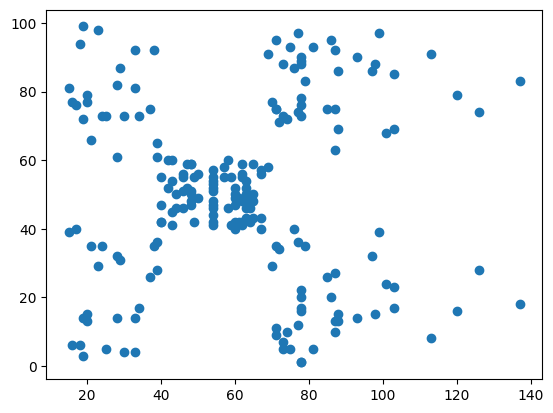

In [8]:
# Đây là file dữ liệu thông tin khách hàng, lưu dạng bảng, nên ta cần sử dụng pandas dataframe để lưu trữ. Dữ liệu lưu trong pandas.dataframe
# Ta co the hien thi cac diem tren du lieu, voi ham matplotlib pyplot

from matplotlib import pyplot as plt
plt.scatter(customers['Annual Income (k$)'], customers['Spending Score (1-100)'])
plt.show()




In [11]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 43.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 43.5 MB/s  0:00:00m0:00:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


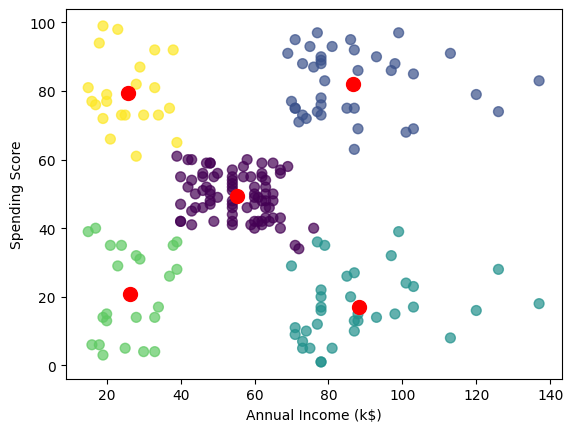

In [12]:
# Ta thay du lieu tren co xu huong chia thanh 5 cum. Do vay ta co the ap dung thuat toan phan cum o day, de nhom cac phan tu gan nhau lai voi nhau:
# Bai toan  " phan cum tren du lieu" nay chinh la "phan loai khach hang" hay "customer segmentation" ma chung ta hay gap:

points = customers.iloc[:, 3:5].values
x = points[:, 0]
y = points[:, 1]

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(points)
predicted_cluster_indexes = kmeans.predict(points)


plt.scatter(x, y, c=predicted_cluster_indexes, s=50, alpha=0.7, cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100)



In [13]:
# Ta thay duoc la nhom khach hang co the chia thanh 5 nhom
# nhom khach hang: (thu nhap it-tieu it); (thu nhap cao- tieu it); (thu nhap cao-tieu nhieu), (thu nhap nhieu-tieu nhieu); (nhom thu nhap trung binh-tieu trung binh)

centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636]])

In [14]:
## Dua vao thong tin phan cum du lieu tren, ta co the tao them 1 truong thong tin tren du lieu
## VD o day: clusterid
customers1 = customers.copy()
customers1['Cluster'] = kmeans.predict(points)
customers1

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,2
197,198,Male,32,126,74,1
198,199,Male,32,137,18,2


In [15]:
# Ta có thể lọc thông tin khách hàng cùng nhóm, VD (thu nhap cao- tieu it):
clustered_df = customers1[customers1['Cluster'] == 2] # Show the customer IDs
clustered_df['CustomerID'].values

array([125, 129, 131, 135, 137, 139, 141, 145, 147, 149, 151, 153, 155,
       157, 159, 161, 163, 165, 167, 169, 171, 173, 175, 177, 179, 181,
       183, 185, 187, 189, 191, 193, 195, 197, 199])

In [16]:
# Độ tuổi trung bình của nhóm này là?
import numpy as np
index =clustered_df['CustomerID'].values
np.average(customers1['Age'][index])


np.float64(32.371428571428574)

In [17]:
# Ví dụ bên trên ta chỉ sử dụng 2 cột thông tin về spending/income để phân cụm khách hàng. Tuy nhiên bộ dữ liệu có cả 5 cột.
# Ngoại trừ cột STT thì 4 trường thông tin khác đều có thể sử dụng để phân nhóm khách hàng.
# để sử dụng thông tin giới tính và tuổi ta cần làm thêm bước tiền xử lý dữ liệu:
data = customers.iloc[:, 1:5].values
data

array([['Male', 19, 15, 39],
       ['Male', 21, 15, 81],
       ['Female', 20, 16, 6],
       ['Female', 23, 16, 77],
       ['Female', 31, 17, 40],
       ['Female', 22, 17, 76],
       ['Female', 35, 18, 6],
       ['Female', 23, 18, 94],
       ['Male', 64, 19, 3],
       ['Female', 30, 19, 72],
       ['Male', 67, 19, 14],
       ['Female', 35, 19, 99],
       ['Female', 58, 20, 15],
       ['Female', 24, 20, 77],
       ['Male', 37, 20, 13],
       ['Male', 22, 20, 79],
       ['Female', 35, 21, 35],
       ['Male', 20, 21, 66],
       ['Male', 52, 23, 29],
       ['Female', 35, 23, 98],
       ['Male', 35, 24, 35],
       ['Male', 25, 24, 73],
       ['Female', 46, 25, 5],
       ['Male', 31, 25, 73],
       ['Female', 54, 28, 14],
       ['Male', 29, 28, 82],
       ['Female', 45, 28, 32],
       ['Male', 35, 28, 61],
       ['Female', 40, 29, 31],
       ['Female', 23, 29, 87],
       ['Male', 60, 30, 4],
       ['Female', 21, 30, 73],
       ['Male', 53, 33, 4],
       ['Male

In [18]:
data[data=='Male']=1
data[data=='Female']=0
data

array([[1, 19, 15, 39],
       [1, 21, 15, 81],
       [0, 20, 16, 6],
       [0, 23, 16, 77],
       [0, 31, 17, 40],
       [0, 22, 17, 76],
       [0, 35, 18, 6],
       [0, 23, 18, 94],
       [1, 64, 19, 3],
       [0, 30, 19, 72],
       [1, 67, 19, 14],
       [0, 35, 19, 99],
       [0, 58, 20, 15],
       [0, 24, 20, 77],
       [1, 37, 20, 13],
       [1, 22, 20, 79],
       [0, 35, 21, 35],
       [1, 20, 21, 66],
       [1, 52, 23, 29],
       [0, 35, 23, 98],
       [1, 35, 24, 35],
       [1, 25, 24, 73],
       [0, 46, 25, 5],
       [1, 31, 25, 73],
       [0, 54, 28, 14],
       [1, 29, 28, 82],
       [0, 45, 28, 32],
       [1, 35, 28, 61],
       [0, 40, 29, 31],
       [0, 23, 29, 87],
       [1, 60, 30, 4],
       [0, 21, 30, 73],
       [1, 53, 33, 4],
       [1, 18, 33, 92],
       [0, 49, 33, 14],
       [0, 21, 33, 81],
       [0, 42, 34, 17],
       [0, 30, 34, 73],
       [0, 36, 37, 26],
       [0, 20, 37, 75],
       [0, 65, 38, 35],
       [1, 24, 38, 92]

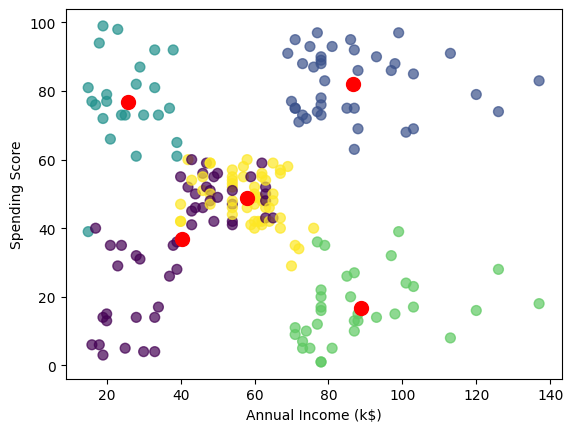

In [19]:
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(data)
predicted_cluster_indexes = kmeans.predict(data)


plt.scatter(data[:,2], data[:,3], c=predicted_cluster_indexes, s=50, alpha=0.7, cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 2], centers[:, 3], c='red', s=100)

# Supervised learning

Đây là nhóm các thuật toán học máy phổ biến nhất, khi ta sử dụng nhãn của subjects trong suốt quá trình huấn luyện và kiểm thử để đánh giá model học máy. Thuật toán phổ biến nhất là phân loại (classification)

In [20]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

iris = datasets.load_iris()

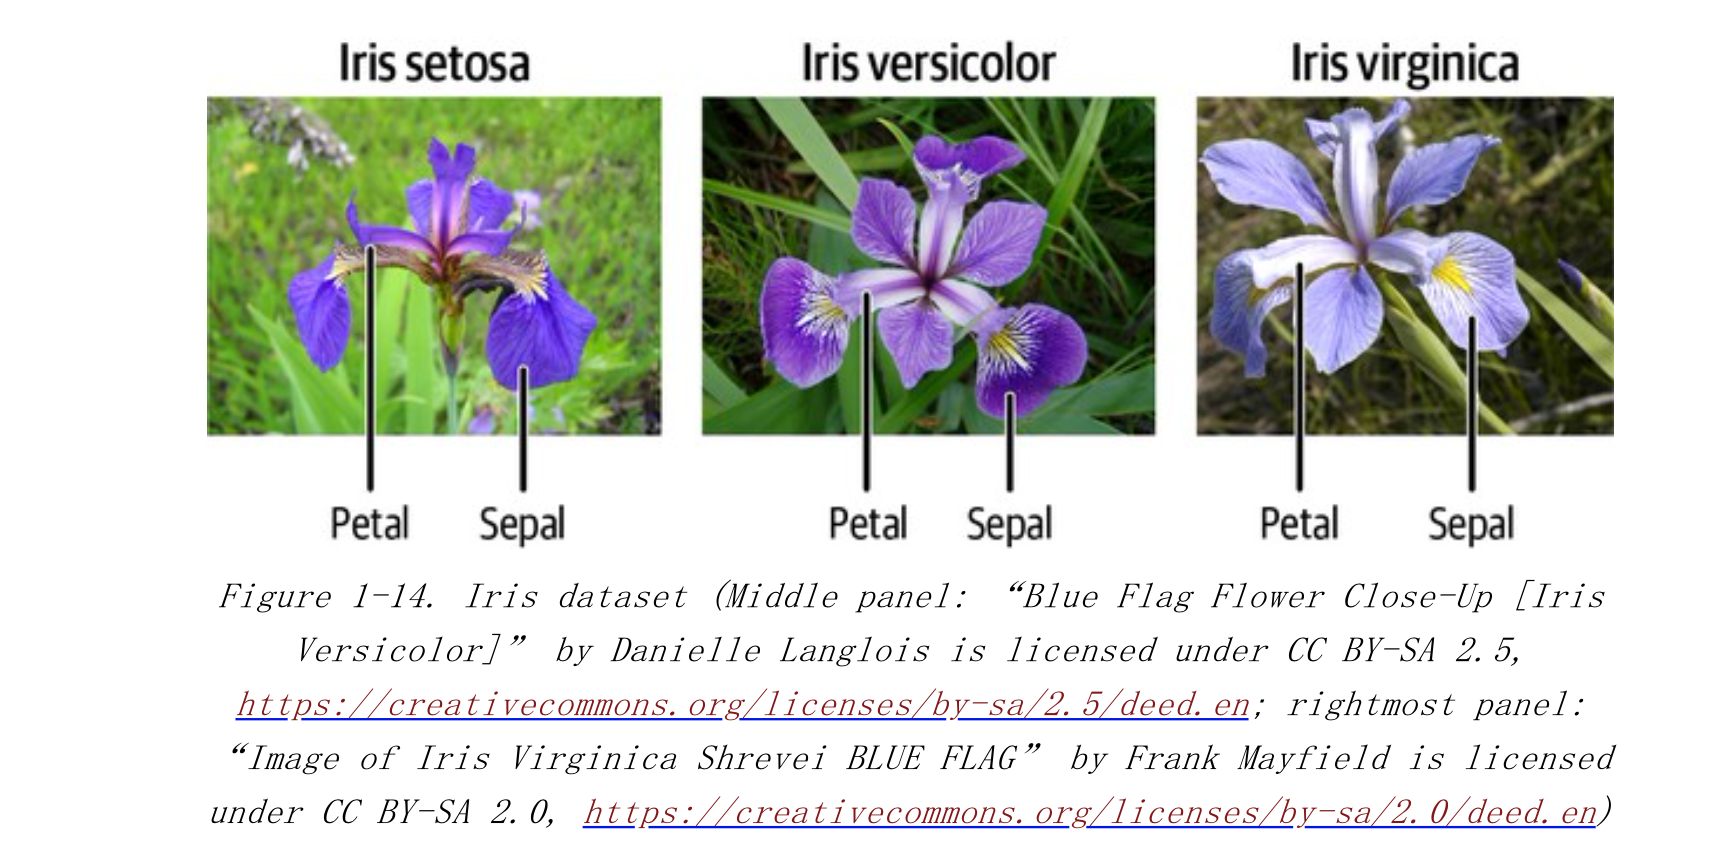

In [21]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

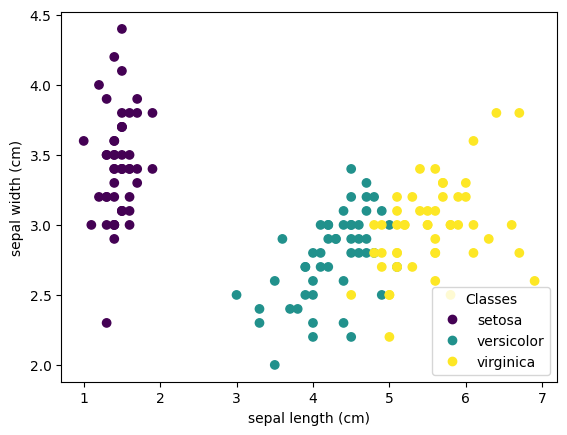

In [22]:
# Cũng có thể hiển thị dữ liệu. Tuy nhiên do dữ liệu 4 chiều (4 columns);
# nên khi vẽ hình, ta có thể chọn 2 chiều bất kỳ để hiển thị. Lưu ý, không bắt buộc phải chọn chiều dài-rộng cánh hoa
# hay dài rộng đài hoa; Các đặc trưng là hoàn toàn độc lập nhau;

import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 2], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes")

In [23]:
# Đây là ví dụ việc sử dụng thư viện sklearn, thực hiện thuật toán KNN.
# Có 3 bước sử dụng:
# Khai báo và chọn tham số cho thuật toán:
# Training===>  .fit trên dữ liệu
# Kiểm thử hay đánh giá với hàm .predict() hoặc .predict_proba()

from sklearn import neighbors

import pylab as pl
from matplotlib.colors import ListedColormap
X, y = iris.data, iris.target

clf = neighbors.KNeighborsClassifier(n_neighbors=5)

clf.fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
# Giả sử ta có một dữ liệu từ 1 bông hoa mới, ta có thể phân loại nó dựa trên mô hình đã có:
result = clf.predict([[1,2,0.6,1]])

print(iris.target_names[result])

['setosa']


In [25]:
# Nếu thực hiện ML mà chưa có dữ liệu ta cần dùng luôn dữ liệu đã có tạo tập training và test.
# Thuật toán train_test_split  sẽ giúp chia dữ liệu thành các phần ngẫu nhiên training và test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [26]:
# Bây giờ dữ liệu có 2 phần ta có thể áp dụng các thuật toán học máy huấn luyện và đánh giá độ chính xác của model:
clf = neighbors.KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))


0.98


In [27]:
from sklearn.svm import SVC
clf1 = SVC(kernel='linear')
clf1.fit(X_train, y_train)
print(clf1.score(X_test, y_test))

1.0


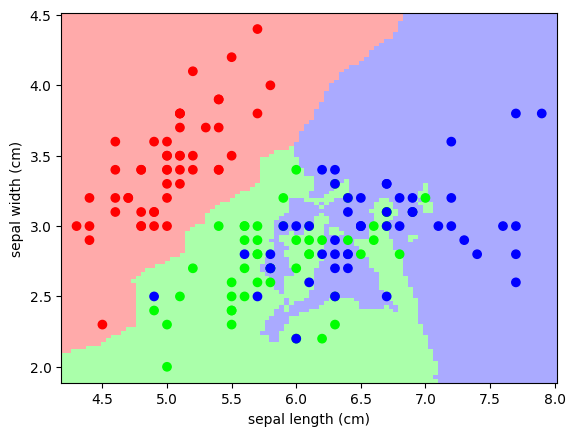

In [28]:
# visualization, kết qủa của bộ phân loại:
import numpy as np

# Định nghĩa 3 mầu để hiển thị:
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

def plot_iris_knn(K):
    iris = datasets.load_iris()
    X = iris.data[:, :2]  # we only take the first two features,
    y = iris.target

    knn = neighbors.KNeighborsClassifier(n_neighbors=K)
    knn.fit(X, y)

    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    pl.figure()
    pl.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    pl.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
    pl.xlabel('sepal length (cm)')
    pl.ylabel('sepal width (cm)')
    pl.axis('tight')

plot_iris_knn(3)

**PCA**




In [29]:
# Ví dụ sử dụng PCA để giảm số chiều dữ liệu. 4 chiều ==> 2 chiều.
# PCA cũng là thuật toán học không có giám sát; không cần thông tin nhãn dữ liệu


import matplotlib.pyplot as plt

from sklearn import datasets       # datasets.load_iris

from sklearn import decomposition  # decomposition.PCA
from sklearn import manifold
pca = decomposition.PCA(n_components = 2)
df_pca = pca.fit_transform(X)
df_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

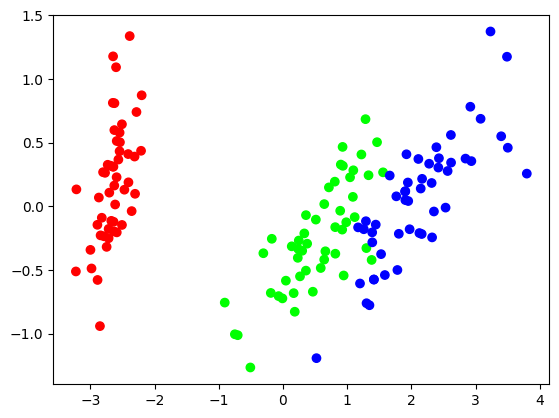

In [30]:
plt.scatter(df_pca[:, 0], df_pca[:,1], c=y, cmap=cmap_bold)

In [31]:
# ví dụ sử dụng cho thuật toán phân cụm==> học không có giám sát hay không dùng thông tin nhãn (y)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
cluster_kmeans = kmeans.fit_predict(X) # id of cluster

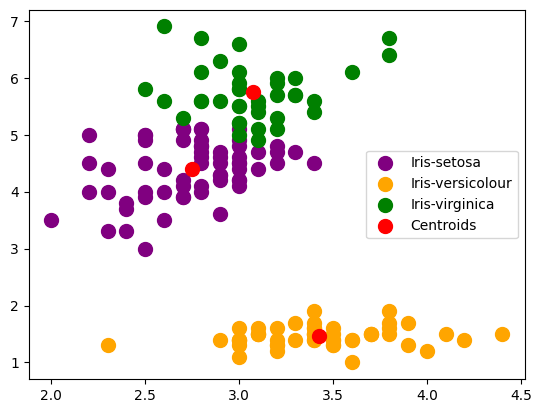

In [32]:
#Visualising the clusters
plt.scatter(X[cluster_kmeans == 0, 1], X[cluster_kmeans == 0, 2], s = 100, c = 'purple', label = 'Iris-setosa')
plt.scatter(X[cluster_kmeans == 1, 1], X[cluster_kmeans == 1, 2], s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(X[cluster_kmeans == 2, 1], X[cluster_kmeans == 2, 2], s = 100, c = 'green', label = 'Iris-virginica')

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:,2], s = 100, c = 'red', label = 'Centroids')

plt.legend()

**Ví dụ trên dữ liệu về bệnh tiểu đường**

In [33]:
## Ví dụ khác về Data in ML:
# dữ liệu lưu dạng df với thư viện pandas

plt.rcParams['figure.figsize'] = [12, 4]
from sklearn import datasets

# Load the diabetes dataset
diabetes = datasets.load_diabetes(as_frame=True)
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [34]:
# Load the diabetes dataset
diabetes_X, diabetes_y = diabetes.data, diabetes.target

# Print part of the dataset
diabetes_X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [35]:
diabetes_X['old_man'] = (diabetes_X['sex'] > 0) & (diabetes_X['age'] > 0.05)
diabetes_X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,old_man
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,False
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,False
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,True
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,False
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,False


Chú ý: 2 thuật ngữ: Features và Attributes.
Attributes là các trường thông tin (columns) vốn có của dữ liệu
Features: đặc trưng, là các dữ liệu dùng trong thuật toán học máy;
nó có thể là Attributes cũng có thể được tạo ra từ các tổ hợp hoặc biến đổi của Attributes.
Qúa trình tạo Features được gọi là trích xuất đặc trưng từ dữ liệu

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(diabetes_X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [37]:
newX=pca.transform(diabetes_X)

In [38]:
newX

array([[-7.29629549e-02,  3.04904280e-02],
       [-8.78166658e-02, -1.29160327e-01],
       [ 9.23157764e-01, -5.83871605e-02],
       [-8.66580315e-02,  1.45155965e-02],
       [-8.16288425e-02, -2.99510940e-02],
       [-9.68419287e-02, -1.79267031e-01],
       [-8.39945765e-02, -9.03562657e-02],
       [ 9.27885602e-01,  2.85724614e-02],
       [-7.32969903e-02,  3.17258338e-02],
       [-8.68391117e-02,  1.44345691e-03],
       [-9.59478328e-02, -1.74686384e-01],
       [-7.41112260e-02,  2.21507650e-02],
       [-8.35302516e-02, -7.05977201e-02],
       [-7.49789770e-02,  1.86955431e-02],
       [-8.19084900e-02, -7.62135226e-02],
       [-7.09175762e-02,  1.47937222e-01],
       [-8.09114754e-02,  1.52664225e-02],
       [ 9.28637669e-01,  3.85589892e-02],
       [-8.65356441e-02, -4.62030655e-02],
       [-8.72727677e-02, -7.63772834e-02],
       [-8.88884466e-02, -8.72874566e-02],
       [-8.67359732e-02, -8.51913024e-02],
       [-9.08502020e-02, -6.89776929e-02],
       [-6.

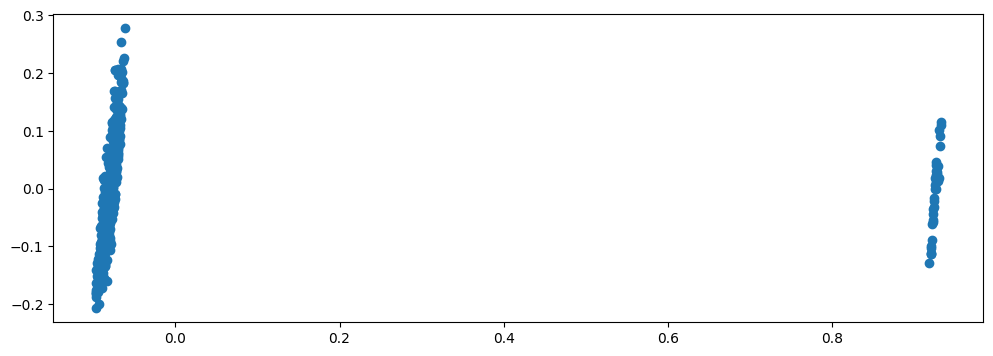

In [39]:
plt.scatter(newX[:,0],newX[:,1])

In [ ]:
# thử phân cụm trên dữ liệu trên:



# Giảm số chiều dữ liệu với PCA


# hiển thị thử dữ liệu, xem khả năng phân cụm =? cụm





In [ ]:
# Một số hàm chúng ta thường sử dụng với sklearn:

# Chia dữ liệu thành train và test:
#sklearn.model_selection.train_test_split(*arrays, test_size=None, \
#train_size=None, random_state=None, shuffle=True, stratify=None)[source]

# Chuẩn hoá dữ liệu:
#Đọc thêm tại
#sklearn.preprocessing.MaxAbsScaler (Python class, in sklearn.preprocessing.MaxAbsScaler)
#sklearn.preprocessing.MinMaxScaler (Python class, in sklearn.preprocessing.MinMaxScaler)
#sklearn.preprocessing.RobustScaler (Python class, in sklearn.preprocessing.RobustScaler)
#sklearn.preprocessing.StandardScaler (Python class, in sklearn.preprocessing.StandardScaler)


#Giảm số chiều dữ liệu:
#PCA


#Cross validation, để đánh giá và tối ưu model:
#from sklearn.model_selection import cross_val_score